In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ['XOM', 'CVX', 'COP', 'MPC', 'PSX', 'VLO']

prices = yf.download(tickers, start='2015-01-01', end='2024-01-01', auto_adjust=True)['Close']
prices.dropna(inplace=True)

print(prices.shape)
print(prices.head())

[*********************100%***********************]  6 of 6 completed

(2264, 6)
Ticker            COP        CVX        MPC        PSX        VLO        XOM
Date                                                                        
2015-01-02  47.917244  69.529404  32.555977  47.927780  32.627335  57.533421
2015-01-05  45.636814  66.750198  31.650057  45.030510  31.285696  55.959190
2015-01-06  43.752655  66.719315  31.337435  43.770813  30.903296  55.661705
2015-01-07  44.044655  66.663719  31.596771  43.963081  30.663488  56.225700
2015-01-08  45.143166  68.189201  32.339260  45.673618  32.419941  57.161568


In [4]:
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import itertools
import matplotlib.pyplot as plt

# Log-transform prices
log_prices = np.log(prices)

# --- TRAIN/TEST SPLIT --- 
# We do this NOW before touching any analysis
log_IS  = log_prices[log_prices.index <= '2020-12-31']
log_OOS = log_prices[log_prices.index >= '2021-01-01']

print(f"In-sample rows:     {len(log_IS)}  ({log_IS.index[0].date()} to {log_IS.index[-1].date()})")
print(f"Out-of-sample rows: {len(log_OOS)}  ({log_OOS.index[0].date()} to {log_OOS.index[-1].date()})")

# --- COINTEGRATION SCREENING (IN-SAMPLE ONLY) ---
tickers_list = list(log_IS.columns)
pairs = list(itertools.combinations(tickers_list, 2))

print(f"\nTesting {len(pairs)} pairs for cointegration...\n")

results = []
for t1, t2 in pairs:
    score, pvalue, _ = coint(log_IS[t1], log_IS[t2])
    results.append((t1, t2, round(pvalue, 4)))

results.sort(key=lambda x: x[2])  # sort by p-value

print(f"{'Pair':<20} {'p-value':<10} {'Cointegrated?'}")
print("-" * 45)
for t1, t2, p in results:
    flag = "✓ YES" if p < 0.05 else "✗ no"
    print(f"{t1} / {t2:<15} {p:<10} {flag}")

In-sample rows:     1511  (2015-01-02 to 2020-12-31)
Out-of-sample rows: 753  (2021-01-04 to 2023-12-29)

Testing 15 pairs for cointegration...

Pair                 p-value    Cointegrated?
---------------------------------------------
COP / MPC             0.0439     ✓ YES
COP / PSX             0.0496     ✓ YES
COP / VLO             0.0529     ✗ no
MPC / VLO             0.1052     ✗ no
CVX / VLO             0.1453     ✗ no
PSX / VLO             0.1509     ✗ no
MPC / PSX             0.1936     ✗ no
CVX / PSX             0.2259     ✗ no
PSX / XOM             0.2374     ✗ no
VLO / XOM             0.3091     ✗ no
CVX / MPC             0.3472     ✗ no
COP / CVX             0.3758     ✗ no
MPC / XOM             0.3799     ✗ no
COP / XOM             0.5421     ✗ no
CVX / XOM             0.5838     ✗ no


COP/MPC → beta=0.6858, alpha=1.1584
COP/PSX → beta=0.8609, alpha=0.1243

ADF Test on IS spreads (p < 0.05 = stationary = good):

COP/MPC → ADF stat=-3.3919, p=0.0112 ✓ Stationary
COP/PSX → ADF stat=-3.3528, p=0.0127 ✓ Stationary


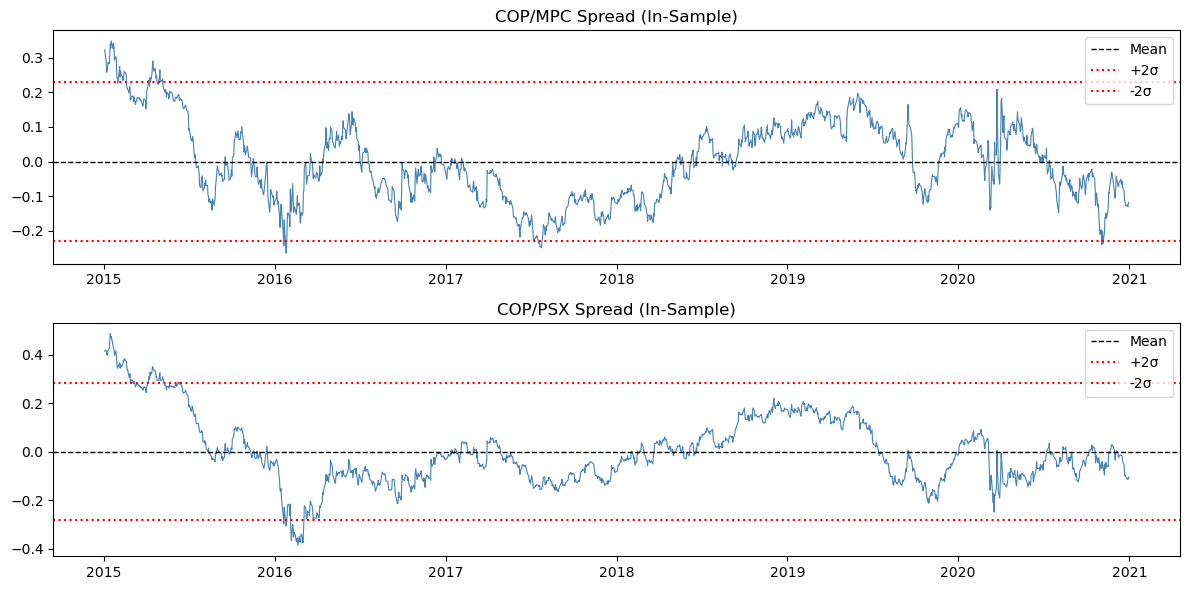

In [5]:
# We'll work with both cointegrated pairs
selected_pairs = [('COP', 'MPC'), ('COP', 'PSX')]

def estimate_hedge_ratio(s1, s2, log_px):
    """OLS regression to find beta: s1 = alpha + beta*s2"""
    y = log_px[s1]
    x = add_constant(log_px[s2])
    model = OLS(y, x).fit()
    beta = model.params[s2]
    alpha = model.params['const']
    return beta, alpha

def compute_spread(s1, s2, log_px, beta, alpha):
    """spread = s1 - beta*s2 - alpha"""
    return log_px[s1] - beta * log_px[s2] - alpha

# --- Estimate hedge ratios IN-SAMPLE ONLY ---
hedge_ratios = {}
for t1, t2 in selected_pairs:
    beta, alpha = estimate_hedge_ratio(t1, t2, log_IS)
    hedge_ratios[(t1, t2)] = (beta, alpha)
    print(f"{t1}/{t2} → beta={beta:.4f}, alpha={alpha:.4f}")

# --- Confirm spreads are stationary with ADF test ---
print("\nADF Test on IS spreads (p < 0.05 = stationary = good):\n")
for t1, t2 in selected_pairs:
    beta, alpha = hedge_ratios[(t1, t2)]
    spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
    adf_stat, adf_p, _, _, _, _ = adfuller(spread_IS)
    print(f"{t1}/{t2} → ADF stat={adf_stat:.4f}, p={adf_p:.4f} {'✓ Stationary' if adf_p < 0.05 else '✗ Not stationary'}")

# --- Plot the spreads ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for i, (t1, t2) in enumerate(selected_pairs):
    beta, alpha = hedge_ratios[(t1, t2)]
    spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
    axes[i].plot(spread_IS, color='steelblue', linewidth=0.8)
    axes[i].axhline(spread_IS.mean(), color='black', linestyle='--', linewidth=1, label='Mean')
    axes[i].axhline(spread_IS.mean() + 2*spread_IS.std(), color='red', linestyle=':', label='+2σ')
    axes[i].axhline(spread_IS.mean() - 2*spread_IS.std(), color='red', linestyle=':', label='-2σ')
    axes[i].set_title(f'{t1}/{t2} Spread (In-Sample)')
    axes[i].legend()
plt.tight_layout()
plt.show()

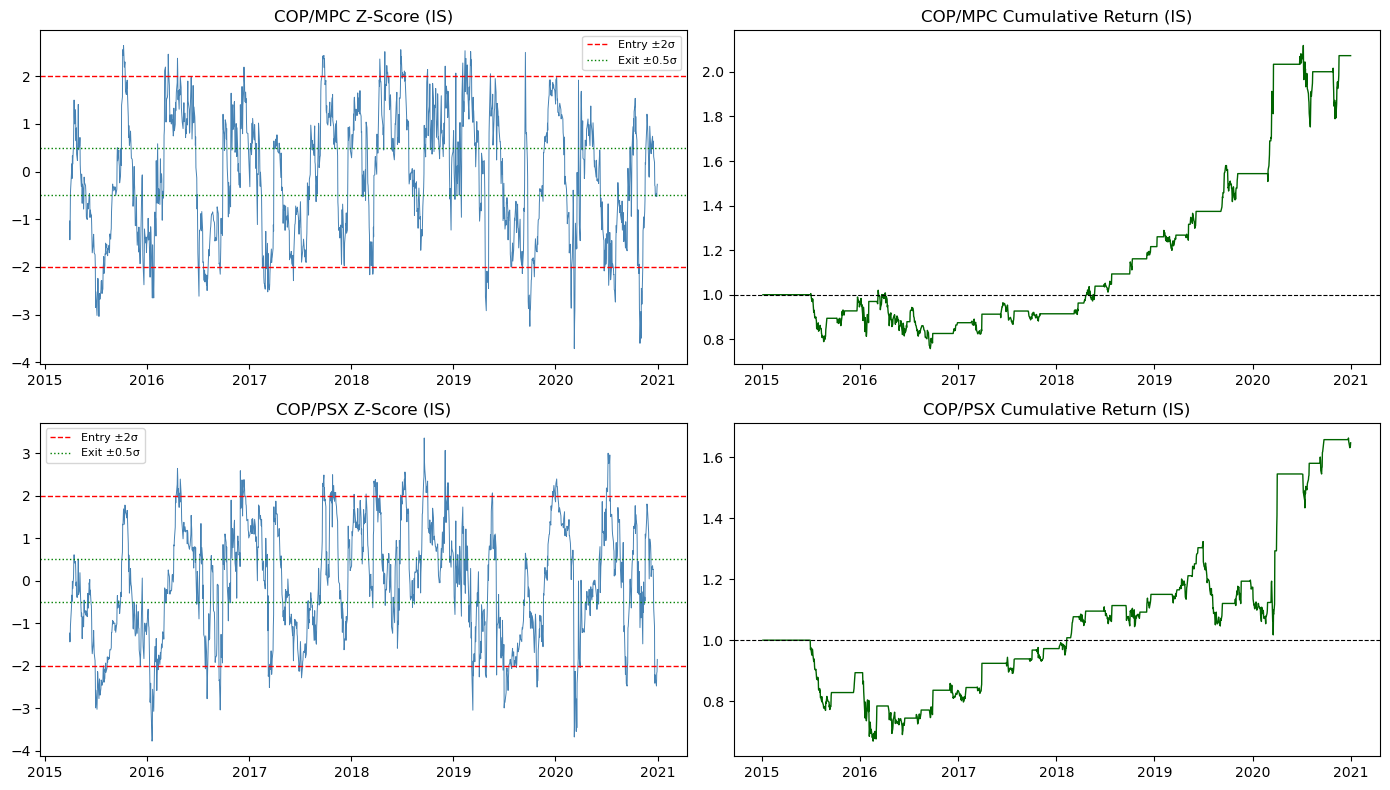


IN-SAMPLE PERFORMANCE

COP/MPC
  Ann. Return:   14.17%
  Ann. Vol:      20.12%
  Sharpe Ratio:  0.704
  Max Drawdown:  -25.68%
  Win Rate:      20.07%

COP/PSX
  Ann. Return:   10.32%
  Ann. Vol:      20.03%
  Sharpe Ratio:  0.515
  Max Drawdown:  -33.14%
  Win Rate:      20.53%


In [6]:
def zscore_rolling(spread, window=60):
    mean = spread.rolling(window).mean()
    std  = spread.rolling(window).std()
    return (spread - mean) / std

def build_positions(z, entry=2.0, exit=0.5):
    pos = pd.Series(0, index=z.index)
    for i in range(1, len(z)):
        prev = pos.iloc[i-1]
        zi   = z.iloc[i]
        if pd.isna(zi):
            pos.iloc[i] = 0
        elif prev == 0:
            if zi >  entry: pos.iloc[i] = -1   # spread too high → short it
            elif zi < -entry: pos.iloc[i] =  1  # spread too low  → long it
        elif prev ==  1 and zi >= -exit: pos.iloc[i] = 0   # close long
        elif prev == -1 and zi <=  exit: pos.iloc[i] = 0   # close short
        else: pos.iloc[i] = prev                            # hold
    return pos

def compute_returns(s1, s2, log_px, positions, beta):
    """Daily P&L: long s1, short beta*s2 (or reverse)"""
    r1 = log_px[s1].diff()
    r2 = log_px[s2].diff()
    spread_returns = r1 - beta * r2
    return positions.shift(1) * spread_returns   # shift(1) prevents look-ahead bias

# --- Build signals and compute IS returns ---
IS_metrics = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (t1, t2) in enumerate(selected_pairs):
    beta, alpha = hedge_ratios[(t1, t2)]
    spread_IS   = compute_spread(t1, t2, log_IS, beta, alpha)
    z_IS        = zscore_rolling(spread_IS)
    pos_IS      = build_positions(z_IS)
    ret_IS      = compute_returns(t1, t2, log_IS, pos_IS, beta)

    # z-score plot
    axes[i][0].plot(z_IS, color='steelblue', linewidth=0.7)
    axes[i][0].axhline( 2.0, color='red',   linestyle='--', linewidth=1, label='Entry ±2σ')
    axes[i][0].axhline(-2.0, color='red',   linestyle='--', linewidth=1)
    axes[i][0].axhline( 0.5, color='green', linestyle=':',  linewidth=1, label='Exit ±0.5σ')
    axes[i][0].axhline(-0.5, color='green', linestyle=':',  linewidth=1)
    axes[i][0].set_title(f'{t1}/{t2} Z-Score (IS)')
    axes[i][0].legend(fontsize=8)

    # cumulative return plot
    cum_ret = (1 + ret_IS).cumprod()
    axes[i][1].plot(cum_ret, color='darkgreen', linewidth=1)
    axes[i][1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
    axes[i][1].set_title(f'{t1}/{t2} Cumulative Return (IS)')

    IS_metrics[(t1,t2)] = ret_IS

plt.tight_layout()
plt.show()

# --- Print IS performance summary ---
print("\nIN-SAMPLE PERFORMANCE\n" + "="*45)
for (t1,t2), ret in IS_metrics.items():
    ret = ret.dropna()
    sharpe   = (ret.mean() / ret.std()) * np.sqrt(252)
    ann_ret  = ret.mean() * 252
    ann_vol  = ret.std()  * np.sqrt(252)
    cum      = (1 + ret).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    win_rate = (ret > 0).mean()
    print(f"\n{t1}/{t2}")
    print(f"  Ann. Return:   {ann_ret:.2%}")
    print(f"  Ann. Vol:      {ann_vol:.2%}")
    print(f"  Sharpe Ratio:  {sharpe:.3f}")
    print(f"  Max Drawdown:  {max_dd:.2%}")
    print(f"  Win Rate:      {win_rate:.2%}")

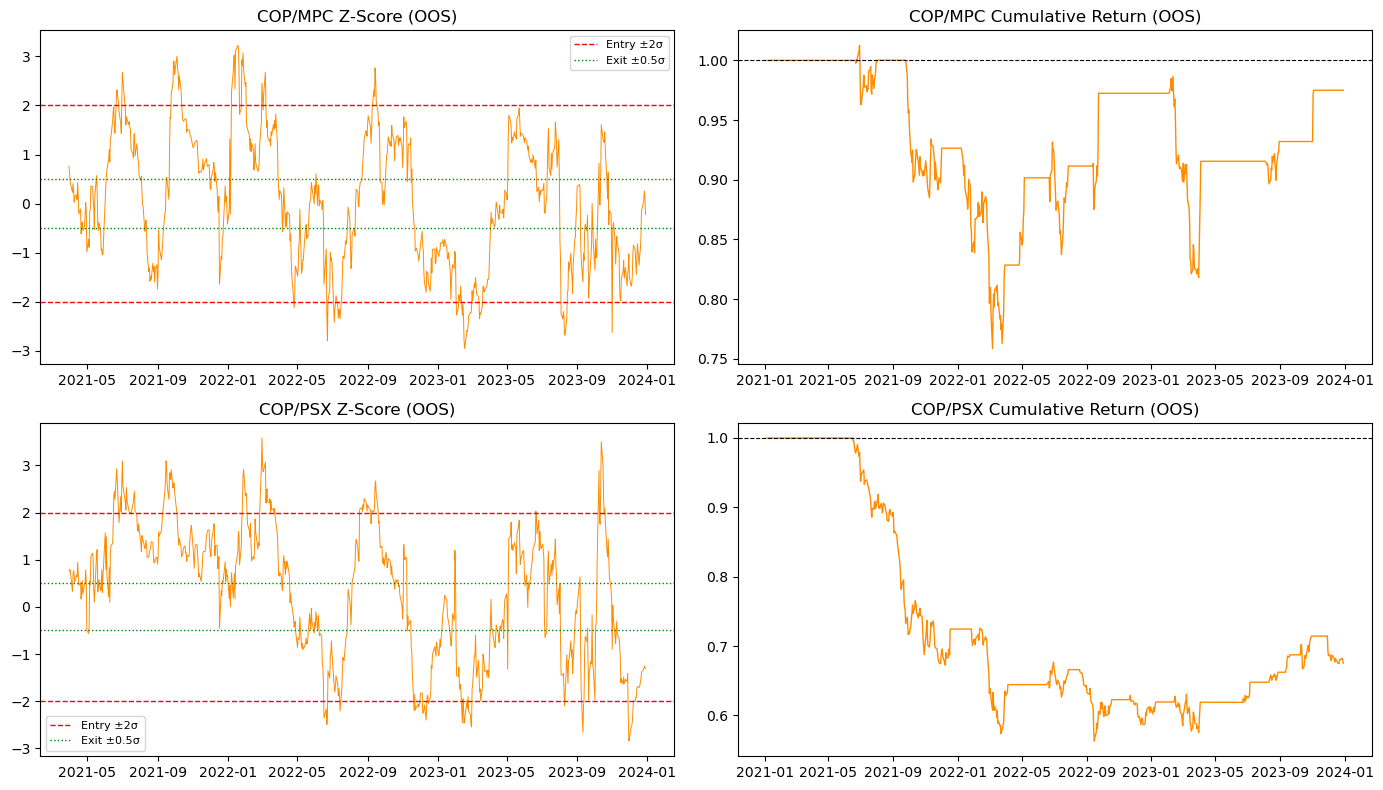


IS vs OOS PERFORMANCE COMPARISON
Metric                 COP/MPC IS  COP/MPC OOS   COP/PSX IS  COP/PSX OOS
------------------------------------------------------------
Sharpe                      0.704        0.013        0.515       -0.718
Ann. Return                14.17%        0.18%       10.32%      -11.80%
Ann. Vol                   20.12%       14.40%       20.03%       16.43%
Max Drawdown              -25.68%      -25.08%      -33.14%      -43.70%
Win Rate                   20.07%       15.03%       20.53%       23.14%


In [7]:
# ================================================================
# OUT-OF-SAMPLE TEST — PARAMETERS FROZEN FROM IN-SAMPLE
# We do NOT re-optimize anything from this point forward
# ================================================================

OOS_metrics = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (t1, t2) in enumerate(selected_pairs):
    # Frozen parameters from IS
    beta, alpha = hedge_ratios[(t1, t2)]
    
    spread_OOS = compute_spread(t1, t2, log_OOS, beta, alpha)
    z_OOS      = zscore_rolling(spread_OOS, window=60)
    pos_OOS    = build_positions(z_OOS, entry=2.0, exit=0.5)
    ret_OOS    = compute_returns(t1, t2, log_OOS, pos_OOS, beta)

    # z-score plot
    axes[i][0].plot(z_OOS, color='darkorange', linewidth=0.7)
    axes[i][0].axhline( 2.0, color='red',   linestyle='--', linewidth=1, label='Entry ±2σ')
    axes[i][0].axhline(-2.0, color='red',   linestyle='--', linewidth=1)
    axes[i][0].axhline( 0.5, color='green', linestyle=':',  linewidth=1, label='Exit ±0.5σ')
    axes[i][0].axhline(-0.5, color='green', linestyle=':',  linewidth=1)
    axes[i][0].set_title(f'{t1}/{t2} Z-Score (OOS)')
    axes[i][0].legend(fontsize=8)

    # cumulative return
    cum_ret = (1 + ret_OOS).cumprod()
    axes[i][1].plot(cum_ret, color='darkorange', linewidth=1)
    axes[i][1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
    axes[i][1].set_title(f'{t1}/{t2} Cumulative Return (OOS)')

    OOS_metrics[(t1,t2)] = ret_OOS

plt.tight_layout()
plt.show()

# --- Side-by-side IS vs OOS comparison table ---
print("\nIS vs OOS PERFORMANCE COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'COP/MPC IS':>12} {'COP/MPC OOS':>12} {'COP/PSX IS':>12} {'COP/PSX OOS':>12}")
print("-" * 60)

def metrics(ret):
    ret = ret.dropna()
    sharpe  = (ret.mean() / ret.std()) * np.sqrt(252)
    ann_ret = ret.mean() * 252
    ann_vol = ret.std()  * np.sqrt(252)
    cum     = (1 + ret).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    win     = (ret > 0).mean()
    return sharpe, ann_ret, ann_vol, max_dd, win

labels = ['Sharpe', 'Ann. Return', 'Ann. Vol', 'Max Drawdown', 'Win Rate']
IS_vals  = [metrics(IS_metrics[p])  for p in selected_pairs]
OOS_vals = [metrics(OOS_metrics[p]) for p in selected_pairs]

formats = ['.3f', '.2%', '.2%', '.2%', '.2%']
for j, label in enumerate(labels):
    row = f"{label:<20}"
    for k in range(2):
        row += f" {IS_vals[k][j]:>12{formats[j]}} {OOS_vals[k][j]:>12{formats[j]}}"
    print(row)
    

In [8]:
# ================================================
# TRANSACTION COSTS + SENSITIVITY ANALYSIS
# ================================================

# --- 1. Transaction Cost Impact on COP/MPC (the surviving pair) ---
cost_bps_list = [0, 5, 10, 20]   # basis points per trade

t1, t2 = 'COP', 'MPC'
beta, alpha = hedge_ratios[(t1, t2)]

print("TRANSACTION COST SENSITIVITY — COP/MPC")
print("=" * 55)
print(f"{'Cost (bps)':<15} {'IS Sharpe':>12} {'OOS Sharpe':>12} {'OOS Ann. Ret':>14}")
print("-" * 55)

for bps in cost_bps_list:
    cost = bps / 10000

    # IS
    spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
    z_IS      = zscore_rolling(spread_IS)
    pos_IS    = build_positions(z_IS)
    ret_IS    = compute_returns(t1, t2, log_IS, pos_IS, beta)
    trades_IS = pos_IS.diff().abs()
    net_IS    = ret_IS - trades_IS * cost
    sh_IS     = (net_IS.mean() / net_IS.std()) * np.sqrt(252)

    # OOS
    spread_OOS = compute_spread(t1, t2, log_OOS, beta, alpha)
    z_OOS      = zscore_rolling(spread_OOS)
    pos_OOS    = build_positions(z_OOS)
    ret_OOS    = compute_returns(t1, t2, log_OOS, pos_OOS, beta)
    trades_OOS = pos_OOS.diff().abs()
    net_OOS    = ret_OOS - trades_OOS * cost
    sh_OOS     = (net_OOS.mean() / net_OOS.std()) * np.sqrt(252)
    ann_OOS    = net_OOS.mean() * 252

    print(f"{bps:<15} {sh_IS:>12.3f} {sh_OOS:>12.3f} {ann_OOS:>14.2%}")

# --- 2. Entry Threshold Sensitivity (IS only — never tune on OOS) ---
print("\n\nENTRY THRESHOLD SENSITIVITY — COP/MPC (In-Sample)")
print("=" * 45)
print(f"{'Entry σ':<12} {'Exit σ':<12} {'IS Sharpe':>12}")
print("-" * 45)

spread_IS = compute_spread(t1, t2, log_IS, beta, alpha)
z_IS      = zscore_rolling(spread_IS)

for entry in [1.5, 2.0, 2.5]:
    for exit_t in [0.25, 0.5, 0.75]:
        pos  = build_positions(z_IS, entry=entry, exit=exit_t)
        ret  = compute_returns(t1, t2, log_IS, pos, beta)
        sh   = (ret.mean() / ret.std()) * np.sqrt(252)
        print(f"{entry:<12} {exit_t:<12} {sh:>12.3f}")

TRANSACTION COST SENSITIVITY — COP/MPC
Cost (bps)         IS Sharpe   OOS Sharpe   OOS Ann. Ret
-------------------------------------------------------
0                      0.704        0.013          0.18%
5                      0.684       -0.008         -0.12%
10                     0.664       -0.029         -0.42%
20                     0.623       -0.072         -1.03%


ENTRY THRESHOLD SENSITIVITY — COP/MPC (In-Sample)
Entry σ      Exit σ          IS Sharpe
---------------------------------------------
1.5          0.25                0.590
1.5          0.5                 0.703
1.5          0.75                0.952
2.0          0.25                0.534
2.0          0.5                 0.704
2.0          0.75                0.967
2.5          0.25                0.657
2.5          0.5                 0.808
2.5          0.75                0.691


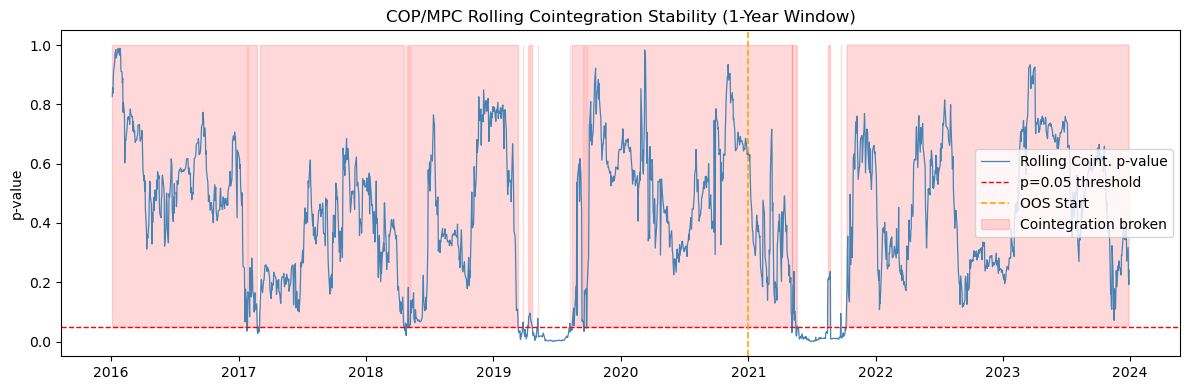

Cointegration held:  206/2012 days (10.2%)
Cointegration broke: 1806/2012 days (89.8%)

Post-2021 breakdown rate: 87.5%


In [9]:
# ================================================
# COINTEGRATION STABILITY ANALYSIS
# Shows WHERE and WHEN the relationship broke down
# ================================================
from statsmodels.tsa.stattools import coint

t1, t2 = 'COP', 'MPC'
full_log = np.log(prices)

window  = 252   # rolling 1-year window
dates   = full_log.index[window:]
pvalues = []

for i in range(len(dates)):
    window_data = full_log.iloc[i : i + window]
    _, pval, _  = coint(window_data[t1], window_data[t2])
    pvalues.append(pval)

pval_series = pd.Series(pvalues, index=dates)

plt.figure(figsize=(12, 4))
plt.plot(pval_series, color='steelblue', linewidth=0.9, label='Rolling Coint. p-value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p=0.05 threshold')
plt.axvline(pd.Timestamp('2021-01-01'), color='orange', 
            linestyle='--', linewidth=1.2, label='OOS Start')
plt.fill_between(pval_series.index, 0.05, 1.0, 
                 where=pval_series > 0.05, alpha=0.15, color='red', 
                 label='Cointegration broken')
plt.title('COP/MPC Rolling Cointegration Stability (1-Year Window)')
plt.ylabel('p-value')
plt.legend()
plt.tight_layout()
plt.show()

# Summary
broken = (pval_series > 0.05).sum()
total  = len(pval_series)
print(f"Cointegration held:  {total-broken}/{total} days ({(total-broken)/total:.1%})")
print(f"Cointegration broke: {broken}/{total} days ({broken/total:.1%})")
print(f"\nPost-2021 breakdown rate: ", end="")
post2021 = pval_series[pval_series.index >= '2021-01-01']
print(f"{(post2021 > 0.05).mean():.1%}")